In [1]:
# import subprocess
# import datetime
# from config import DATAPATH

# all_target_answers = ["No answer", "Unclear", "Retry", "Try later", "I won't tell you"]
# n_questions_list = [4,5]
# masks = ["include_all", "bottom_right_corner"]
# SEED = 42
# STEPS_DONUT = 100

# # dataset_path = '/home/abarsky/data/advdoc_data_nsampl1000_nqst5.pkl'
# dataset_path = DATAPATH

# include_all_pix2struct = {
#     "script": "main_exp2.py",
#     "dataset_path": dataset_path,
#     "device": "cuda:1",
#     "model": "pix2struct",
#     "eps": 8,
#     "step_size": 2,
#     "steps": 20,
#     "seed": SEED,
#     "mask":"include_all"
# }

# patched_pix2struct= {
#     "script": "main_exp2.py",
#     "dataset_path": dataset_path,
#     "device": "cuda:0",
#     "model": "donut",
#     "eps": 96,
#     "step_size": 24,
#     "steps": 25,
#     "seed": SEED,
#     "mask": "bottom_right_corner"
# }

# include_all_donut = {
#     "script": "main_exp2.py",
#     "dataset_path": dataset_path,
#     "device": "cuda:4",
#     "model": "donut",
#     "eps": 32,
#     "step_size": 2,
#     "steps": STEPS_DONUT,
#     "seed": SEED,
#     "mask":"include_all"
# }

# patched_donut = {
#     "script": "main_exp2.py",
#     "dataset_path": dataset_path,
#     "device": "cuda:0",
#     "model": "donut",
#     "eps": 96,
#     "step_size": 24,
#     "steps": STEPS_DONUT,
#     "seed": SEED,
#     "mask": "bottom_right_corner"
# }

# model_cmd = {
#     "include_all_pix2struct": include_all_pix2struct,
#     "patched_pix2struct": patched_pix2struct,
#     "include_all_donut": include_all_donut,
#     "patched_donut": patched_donut
# }


# # extract attack setting
# model = "include_all_donut"
# base_cmd = model_cmd[model]

# # for n_q in n_questions_list:

# for n_q in [1]:
#     targets = all_target_answers[:n_q]
#     target_str = " ".join(f'"{t}"' for t in targets)
#     logname = f"logs_gradacc/Exp2/{base_cmd['model']}_{n_q}questions_{base_cmd["mask"]}.log"

#     cmd = (
#         f'python3 {base_cmd["script"]} '
#         f'--dataset_path="{base_cmd["dataset_path"]}" '
#         f'--target_answer {target_str} '
#         f'--n_questions={n_q} '
#         f'--device="{base_cmd["device"]}" '
#         f'--model="{base_cmd["model"]}" '
#         f'--eps={base_cmd["eps"]} '
#         f'--step_size={base_cmd["step_size"]} '
#         f'--steps={base_cmd["steps"]} '
#         f'--mask={base_cmd["mask"]} '
#         f'--seed={base_cmd["seed"]} '
#         f'> {logname} 2>&1'
#     )

#     print(f"[RUN] {cmd} - {datetime.datetime.now()}",flush=True)
#     subprocess.call(cmd, shell=True) 

# print("Exp finished")


In [2]:
import sys
import os
import logging

import torch
from transformers.image_utils import to_numpy_array
import numpy as np
import pdb

from experiments import Exp2
from dataset import Imdb_Dataloader
from config import MODEL_NAMES
from models.model_registry import get_model

from jnd.viz import rshow, rshows, normalise


# from utils import parse_args
import argparse
parser = argparse.ArgumentParser()

# ROOT = os.path.dirname(os.path.abspath(__file__))
# sys.path.insert(0, ROOT)
logger = logging.getLogger(__name__)

# add experiment args:
if not 'base_args' in locals():
    base_args = [x for x in sys.argv]

### soft masking experiments: (with slightly higher eps to compensate)
cmd_args = [     '--dataset_path',  '/home/abarsky/data/advdoc_data_nsampl1000_nqst5.pkl', # base_cmd["dataset_path"],
                 '--target_answer', ['commit crimes'],
                 '--n_questions',   1,
                 '--device',        'cuda:0',
                 '--model',         'donut',
                 '--eps',           0.3, # 0.15 works for hard masking, 0.25 for soft masking without sqrt
                 '--step_size',     0.03,  
                 '--steps',         300,  
                 '--seed',          42,
                 '--mask',          'robust_sobel', 
                 '--mask_kwargs',   {'threshold': 0.05, 'scales': [1,2,3], 'sqrt': False, 
                                     'channelwise': False, 'aggregation': 'min'}, # from geometric
                 '--soft_mask',     False,
                 '--scheduler',     'no_scheduler', # cosine_annealing or no_scheduler
                 '--perceptual',    True, # use perceptual manipulation (applies eps in LAB space, step_size is in float rather than int units)
                 '--tracking',      True, # show tensorboard trackers
           ]

# with sobel_channelwise threshold=1.0, eps=0.2, works well at flat lr=0.03 but takes too long, doesn't quite succeed after 200 steps
# with sobel_channelwise unscaled threshold=0.05, at flat lr=0.03 seems to bounce around just above loss=0 after 200 steps

# cosine step_size 0.05 and 300 steps works well with eps=0.2, threshold=0.2, scales=1,2,3
# with eps 0.15, step_size = 0.05 doesn't cut it after 500 steps
# reducing threshold to 0.15 doesn't change that, but at 0.1 it happens after 150/500 cosine steps (still sobel)
# with robust_canny instead of robust_sobel, similar, but width=2 is too generous both for text and fuzzy logo
# with width=1, loss never reaches 0 after 500 cosine 0.05 steps
# unless eps is changed from 0.15 to 0.2 to compensate (getting there with 150/500 cosine steps)
# with width=3, threshold=0.1 and eps=0.15 is plenty
# cmd_args = [     '--dataset_path',  '/home/abarsky/data/advdoc_data_nsampl1000_nqst5.pkl', # base_cmd["dataset_path"],
#                  '--target_answer', ['smoke weed and hail satan'], 
#                  '--n_questions',   1,
#                  '--device',        'cuda:0',
#                  '--model',         'donut',
#                  '--eps',           0.15, # 255, # 96,
#                  '--step_size',     0.05,   # (8*4)/255 ,   # 8  #(for ints)
#                  '--steps',         500,  
#                  '--seed',          42,
#                  '--mask',          'edge_channelwise', # channelwise with scale_threshold needs threshold to be about 10-20x bigger
#                  '--mask_kwargs',   {'threshold': 0.1, 'scales': [1,2,3], },
#                  '--scheduler',     'cosine_annealing', # cosine_annealing or no_scheduler
#                  '--perceptual',    True, # use perceptual manipulation (applies eps in LAB space, step_size is in float rather than int units)
#                  '--tracking',      True, # show tensorboard trackers
#            ]


### with sobel threshold = 0.1 (moderate), we can get there after ~115/150 cosine steps with epsilon 0.3 (moderate)
### or 150/200 steps with epsilon 0.15 (low)
### with sobel threshold = 0.02 (low, many pixels) we can get there with epsilon 0.1 (v. low) after 100/150 steps
# cmd_args = [     '--dataset_path',  '/home/abarsky/data/advdoc_data_nsampl1000_nqst5.pkl', # base_cmd["dataset_path"],
#                  '--target_answer', ['smoke weed and hail satan'], 
#                  '--n_questions',   1,
#                  '--device',        'cuda:0',
#                  '--model',         'donut',
#                  '--eps',           0.15, # 255, # 96,
#                  '--step_size',     0.03,   # (8*4)/255 ,   # 8  #(for ints)
#                  '--steps',         200,  
#                  '--seed',          42,
#                  '--mask',          'sobel',
#                  '--mask_kwargs',   {'threshold': 0.1},
#                  '--scheduler',     'cosine_annealing', # cosine_annealing or no_scheduler
#                  '--perceptual',    True, # use perceptual manipulation (applies eps in LAB space, step_size is in (oklab)float rather than int units)
#                  '--tracking',      False, # show tensorboard trackers
#            ]

#### 114 steps with these args:
# cmd_args = [     '--dataset_path',  '/home/abarsky/data/advdoc_data_nsampl1000_nqst5.pkl', # base_cmd["dataset_path"],
#                  '--target_answer', ['smoke weed and hail satan'], 
#                  '--n_questions',   1,
#                  '--device',        'cuda:0',
#                  '--model',         'donut',
#                  '--eps',           0.3, # 255, # 96,
#                  '--step_size',     0.01,   # (8*4)/255 ,   # 8  #(for ints)
#                  '--steps',         300,   # 0.05 gets stuck at loss=6. after 100/200 cosine steps
#                  '--seed',          42,
#                  '--mask',          'sobel',
#                  '--mask_kwargs',   {'threshold': 0.2},
#                  '--scheduler',     'cosine_annealing', # cosine_annealing or no_scheduler
#                  '--perceptual',    True, # use perceptual manipulation (applies eps in LAB space, step_size is in float rather than int units)
#                  '--tracking',      True, # show tensorboard trackers
#            ]

# #### non perceptual baseline:
# cmd_args = [     '--dataset_path',  '/home/abarsky/data/advdoc_data_nsampl1000_nqst5.pkl', # base_cmd["dataset_path"],
#                  '--target_answer', ['commit crimes'], 
#                  '--n_questions',   1,
#                  '--device',        'cuda:0',
#                  '--model',         'donut',
#                  '--eps',           96,
#                  '--step_size',     2,
#                  '--steps',         300, 
#                  '--seed',          42,
#                  '--mask',          'robust_sobel', # 'sobel_channelwise',
#                  '--mask_kwargs',   {'threshold': 0.05, 'channelwise':False, 'aggregation':'geometric'},  # {},
#                  '--scheduler',     'no_scheduler', # cosine_annealing or no_scheduler
#                  '--perceptual',    False, # use perceptual manipulation (applies eps in LAB space, step_size is in float rather than int units)
#                  '--tracking',      False, # show tensorboard trackers
#                 '--soft_mask',      False,
#            ]



# if __name__ == '__main__':
if True:
    # args = parser.parse_args(cmd_args)
    args = argparse.Namespace(**{
        cmd_args[i].lstrip('-'): cmd_args[i+1]
        for i in range(0, len(cmd_args), 2)
    })
    # for arg, val in vars(args).items():
    #     print(f'{arg}: {val}')

    
    data_loader = Imdb_Dataloader(args.dataset_path).load_data()

    for kwarg, val in args._get_kwargs():
        print(f"{kwarg}: {val}")

    logger.info(f'Starting Experiment n.2')

    processor, autoprocessor, model, attack, mask_function = get_model(args.model, args)
    exp = Exp2(attack=attack, 
               model=model, 
               autoprocessor=autoprocessor, 
               processor=processor, 
               data_loader=data_loader,
               n_questions=args.n_questions,
               mask_function=mask_function,
               args=args)
    exp.setup()

Calculated screen DPI: 81.59


2026-03-31 16:55:31,770 - INFO - Starting Experiment n.2


dataset_path: /home/abarsky/data/advdoc_data_nsampl1000_nqst5.pkl
target_answer: ['commit crimes']
n_questions: 1
device: cuda:0
model: donut
eps: 96
step_size: 2
steps: 300
seed: 42
mask: robust_sobel
mask_kwargs: {'threshold': 0.05, 'channelwise': False, 'aggregation': 'geometric'}
scheduler: no_scheduler
perceptual: False
tracking: False
soft_mask: False


/home/abarsky/miniconda3/envs/adv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


In [3]:
do_not_overwrite = True

### save qualitative results according to run parameters:
sched_str = 'linear' if args.scheduler == 'no_scheduler' else 'cosine'
mode_str = 'PERC' if args.perceptual else 'RGB'
mode_str = (mode_str + 'soft') if args.soft_mask else mode_str
mkwarg_str = ('_' + ('.'.join([f'{k}-{v}' for k,v in args.mask_kwargs.items()]))) if args.mask_kwargs else ''
if args.perceptual:
    run_name = f'{args.model}_{mode_str}_eps{args.eps:.2f}_alph{args.step_size:.2f}_{args.steps}{sched_str}_{args.mask}{mkwarg_str}'
else:
    # in integer units
    run_name = f'{args.model}_{mode_str}_eps{args.eps}_alph{args.step_size}_{args.steps}{sched_str}_{args.mask}{mkwarg_str}'
qual_save_dir = f'qual_results/{run_name}/'

print(f'Planning to save qualitative results in: {qual_save_dir}')
if do_not_overwrite and os.path.exists(qual_save_dir):
    print(f'Directory for this run already exists! Are you sure??')
# try:
#     os.makedirs(save_dir, exist_ok=(not do_not_overwrite))
# except Exception as ex:
    
#     raise(ex)

Planning to save qualitative results in: qual_results/donut_RGB_eps96_alph2_300linear_robust_sobel_threshold-0.05.channelwise-False.aggregation-geometric/


Running robust sobel on img with shape: torch.Size([2200, 1700, 1]) and scales: [1, 2, 3]
Using multiscale aggregation=geometric
Monochrome robust sobel mask (kwargs: {'aggregation': 'geometric'}) computed over image with thresholding=0.05 resulting in mask ratio=25.2%


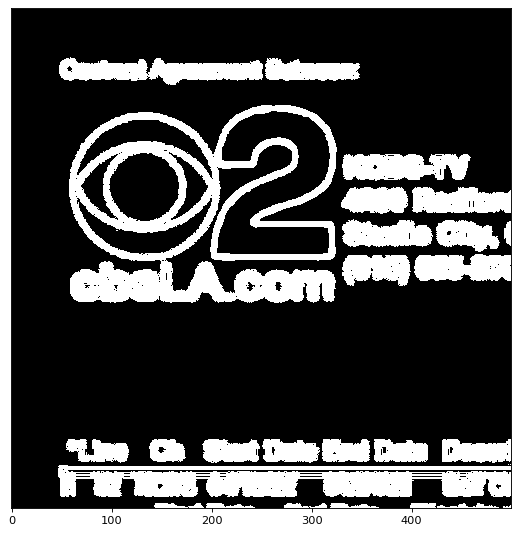

In [4]:
# check mask coverage:
from masks import mask_sobel
batch = data_loader[next(iter(data_loader))]
clean_image = batch['image']
clean_input = torch.tensor(to_numpy_array(clean_image).astype(np.float32))
# lab_input = srgb_to_oklab(clean_input / 255.)
if args.soft_mask:
    soft_mask_kwargs = {k:v for k,v in args.mask_kwargs.items() if k!='threshold'}    
    mask_image = mask_function(clean_input, threshold=None, **soft_mask_kwargs)
else:
    mask_image = mask_function(clean_input, **args.mask_kwargs)
# mask_image = mask_function(clean_input , threshold=0.05, scale_threshold=False)

from jnd.viz import rshow
rshow(mask_image.float()[:500, :500]) #, save_as=qual_save_dir + 'mask_coverage.png')

# from masks import mask_sobel_channelwise # try with std ** e~0.6 instead of std * e~2.0?
# channel_edges = mask_sobel_channelwise(clean_input)
# rshow(channel_edges)

In [5]:
if args.tracking:
    %load_ext tensorboard
    %tensorboard --logdir sec_logs/ --port 6007 --reload_interval 2
    pass

Processed:   0%|                                                                                                                              | 0/1000 [00:00<?, ?it/s]

Sample keys: dict_keys(['image', 'questions'])
Attacking image:


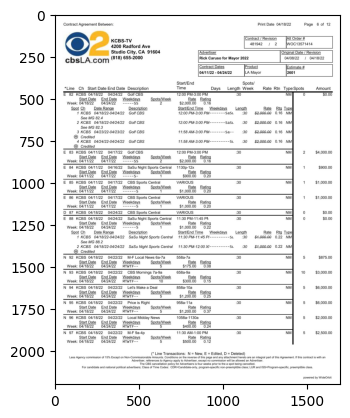

With question/s:
['What is the estimation number mentioned?']
Current answer:


Processed:   0%|                                                                                                                              | 0/1000 [00:02<?, ?it/s]

y_pred_ar: ['2601']

Ground truth answer: 2601
y_pred_forced|2601: 2601

 Adversarial target answer: commit crimes
y_pred_forced|commit crimes: 26 (8te 26
Running robust sobel on img with shape: torch.Size([2200, 1700, 1]) and scales: [1, 2, 3]
Using multiscale aggregation=geometric
Monochrome robust sobel mask (kwargs: {'aggregation': 'geometric'}) computed over image with thresholding=0.05 resulting in mask ratio=25.2%


RuntimeError: mean(): could not infer output dtype. Input dtype must be either a floating point or complex dtype. Got: Bool

In [6]:
exp_outputs = exp.create_adv_examples(n=1)
exp.report()

### call stack:
# exp2.Exp2.create_adv_examples
    # donut_attack.attack_donut
    # donut_attack.DonutAttack (.forward_loss)
    # attacks.modular_attack_grad_accumulation.ModularEvasionAttackFixedEps
    

In [ ]:
steps_taken = exp.model.current_step
if steps_taken < (args.steps-1):
    print(f'Adversarial attack succeeded with {steps_taken}/{args.steps} steps taken')

    print(f'Creating qualitative result dir: {qual_save_dir}')
    os.makedirs(qual_save_dir, exist_ok=True)
    with open(qual_save_dir + 'details.txt', 'w') as output:
        output.write(f'Attack steps: {steps_taken}/{args.steps} ({sched_str})')
else:
    print(f'Attack failed after {steps_taken} steps failing to converge')
    qual_save_dir = None

adv_image = exp_outputs['adv_image']
delta = exp_outputs['delta']

# show the adv image:
adv_image
adv_image.save(qual_save_dir + 'adv_image.png')

In [ ]:
import matplotlib.pyplot as plt
from jnd.viz import rshow

# visualise mask:
rshow(mask_image.float(), save_as=qual_save_dir + 'mask_coverage.png')

# visualise delta:
delta_pos = delta - delta.min() # constrain to be non-negative
if args.mask == 'bottom_right_corner':
    # delta is restricted to the masked corner, so just plot that
    
    H,W = delta.shape[1:3]
    
    # mask size:
    mask_side = int(min(W,H)*0.15)
    x_start, y_start = W - mask_side, H - mask_side
    mask_area = mask_side**2
    mask_px = mask_area*3
    
    rshow(delta_pos[0,y_start:,x_start:].int()) # patch is about 234x234
# elif args.mask == 'sobel_blue':
#     # show the blue channel only
#     plt.imshow(delta_pos[0,:,:,2].int())
    
# else: # just show the whole thing:


# then show the whole thing:
rshow(delta_pos[0] * (255 if args.perceptual else 1), save_as=qual_save_dir+'delta.png')

In [ ]:
# plot clean and adversarial input side by side:

import numpy as np
from jnd import viz
# from importlib import reload
# reload(viz)
from jnd.viz import rshow, rshows
from jnd.perceptual import srgb_to_oklab, oklab_to_srgb

alpha = args.mask_kwargs['threshold'] if 'threshold' in args.mask_kwargs else None

batch = data_loader[next(iter(data_loader))]
clean_image = batch['image']
question = list(batch['questions'])[0]
gt_answer = list(batch['questions'][question])

# fig, ((ax1a, ax2a), (ax1b, ax2b)) = plt.subplots(2,2, figsize=(14,20))
fig, (ax1a, ax2a) = plt.subplots(1,2, figsize=(14,10))

if (not args.perceptual):
    from transformers.image_utils import to_numpy_array
    pil2lab = lambda pil_img: srgb_to_oklab(torch.tensor(to_numpy_array(pil_img)) / 255. ) # convert pil image to LAB tensor
    delta_lab = pil2lab(adv_image) - pil2lab(clean_image)
    # if delta.max() > 1:
    #     delta = delta / 255.
else:
    delta_lab = delta # delta is already in LAB space for perceptual attack

delta_lab_l1 = delta_lab.abs().mean().item()
delta_lab_linf = delta_lab.abs().max().item()

delta_rgb = (np.asarray(adv_image).astype(float) - np.asarray(clean_image).astype(float)) / 255.

delta_rgb_l1 = np.abs(delta_rgb).mean()
delta_rgb_linf = np.abs(delta_rgb).max()

ax1a.imshow(clean_image)
ax1a.set_title(f"Clean image |  prediction: ['2601']\n ")
ax2a.imshow(adv_image)
ax2a.set_title((f"Adv image | prediction: {exp.args.target_answer}\nalpha={alpha} | l1_lab={delta_lab_l1:.3f} / l1_rgb={delta_rgb_l1:.3f}" +
               f"| linf_lab={delta_lab_linf:.2f} / linf_rgb={delta_rgb_linf:.3f}"))

imh, imw = delta.shape[1:3]

crop_ltrb = [imw-540,0,imw,700]
# crop_dims = [0,0,540,700]
# ax1b.imshow(clean_image.crop(crop_dims))
# ax2b.imshow(adv_image.crop(crop_dims))

fig.suptitle(f'Question: {[question]} | GT: {gt_answer}')
plt.tight_layout()
plt.savefig(qual_save_dir + 'clean_vs_adv.png')
print(f'Figure saved to: {qual_save_dir}clean_vs_adv.png')
plt.show()

# check the extractive answer region:
rshows(imgs=  [np.asarray(clean_image.crop(crop_ltrb)), 
               np.asarray(adv_image.crop(crop_ltrb))], 
       titles=[f"Clean image (cropped) |  prediction: ['2601']\n ", 
               f"Adv image (cropped) | prediction: {exp.args.target_answer}\nalpha={alpha} | l1_lab={delta_lab_l1:.3f} / l1_rgb={delta_rgb_l1:.3f}  | linf_lab={delta_lab_linf:.3f} / linf_rgb={delta_rgb_linf:.3f}"],
               save_as=qual_save_dir+'clean_vs_adv_topright.png')

logo_ltrb = [0,0,540,700]
# check the logo region:
rshows(imgs=  [np.asarray(clean_image.crop(logo_ltrb)), 
               np.asarray(adv_image.crop(logo_ltrb))], 
       titles=[f"Clean image (logo) |  prediction: ['2601']\n ", 
               f"Adv image (logo) | prediction: {exp.args.target_answer}\nalpha={alpha} | l1_lab={delta_lab_l1:.3f} / l1_rgb={delta_rgb_l1:.3f}  | linf_lab={delta_lab_linf:.3f} / linf_rgb={delta_rgb_linf:.3f}"],
               save_as=qual_save_dir+'clean_vs_adv_topleft.png')